# 119 API 결과 시각화

`119_공공API_연동.ipynb`에서 수집한 결과를 시각화합니다.

- **1. 소방청 구급통계 API** 결과 → 자치구별 출동/이송 현황
- **2. 실시간 응급실 가용병상 API** 결과 → 자치구별 응급실 가용병상 현황

API 노트북에서 아래 두 파일을 미리 저장해두면 이 노트북이 바로 그 결과를 읽어옵니다. (아직 서비스키가 없어 API를 못 돌리셨다면, 1번 섹션은 지금까지의 정적 전처리 결과(`ambulance_prophet.csv`)로 대체 시연하고, 2번 섹션은 파일이 없다는 안내만 출력합니다 — 실제 병상 수치를 임의로 만들어 보여주지 않습니다.)

| API 노트북에서 저장하는 파일 | 이 노트북이 찾는 경로 |
|---|---|
| `collect_latest_month_all_gu(ym)` 결과 | `OUT_DIR/ambulance_prophet_<YYYYMM>_api.csv` |
| `collect_realtime_beds_all_gu()` 결과 | `OUT_DIR/realtime_er_beds.csv` |


## 0. 환경 설정 (12장 시각화 컨벤션)

In [10]:
import glob
import os
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import seaborn as sns
import warnings

warnings.filterwarnings(action='ignore')


def set_korean_font():
    """OS별 한글 폰트를 자동으로 찾아 matplotlib에 강제 등록"""
    candidates_by_path = [
        "C:/Windows/Fonts/malgun.ttf",                               # Windows 맑은 고딕
        "C:/Windows/Fonts/malgunbd.ttf",
        "/System/Library/Fonts/Supplemental/AppleGothic.ttf",       # macOS
        "/System/Library/Fonts/AppleSDGothicNeo.ttc",
        "/usr/share/fonts/truetype/nanum/NanumGothic.ttf",          # Linux(나눔고딕)
        "/usr/share/fonts/truetype/nanum/NanumGothicBold.ttf",
    ]
    for path in candidates_by_path:
        if os.path.exists(path):
            fm.fontManager.addfont(path)
            font_name = fm.FontProperties(fname=path).get_name()
            plt.rcParams['font.family'] = font_name
            print(f"[폰트] 한글 폰트 적용: {font_name}  ({path})")
            return font_name

    installed = {f.name for f in fm.fontManager.ttflist}
    for name in ["Malgun Gothic", "NanumGothic", "NanumBarunGothic", "AppleGothic", "AppleSDGothicNeo"]:
        if name in installed:
            plt.rcParams['font.family'] = name
            print(f"[폰트] 한글 폰트 적용: {name}")
            return name

    print("[경고] 한글 폰트를 찾지 못했습니다.")
    return None

sns.set_style('dark') 
set_korean_font() 
plt.rcParams['axes.unicode_minus'] = False  
plt.rcParams['figure.figsize'] = (12, 5)

OUT_DIR = "C:/Users/Admin/Desktop/1st_project/data/outputs"

[폰트] 한글 폰트 적용: Malgun Gothic  (C:/Windows/Fonts/malgun.ttf)


---
## 1. 소방청 구급통계 API 결과 — 자치구별 출동·이송 현황

`collect_latest_month_all_gu(ym)`으로 만든 `ambulance_prophet_<YYYYMM>_api.csv`가 있으면 그걸 쓰고,
없으면 기존 전처리 결과(`ambulance_prophet.csv`)의 가장 최근 연도로 대체해 구조를 보여드립니다.

In [11]:
api_files = sorted(glob.glob(f"{OUT_DIR}/ambulance_prophet_*_api.csv"))

if api_files:
    latest_file = api_files[-1]
    fire_df = pd.read_csv(latest_file)
    data_source_label = os.path.basename(latest_file)
    print(f"API 수집 결과 사용: {data_source_label}")
else:
    fire_df = pd.read_csv(f"{OUT_DIR}/ambulance_prophet.csv")
    fire_df['ds'] = pd.to_datetime(fire_df['ds'])
    latest_year = fire_df['ds'].dt.year.max()
    fire_df = fire_df[fire_df['ds'].dt.year == latest_year].copy()
    data_source_label = f"ambulance_prophet.csv ({latest_year}년, API 대체 시연)"
    print(f"[안내] API 결과 파일이 아직 없어 정적 전처리 데이터로 대체합니다: {data_source_label}")

fire_df = fire_df.sort_values('y', ascending=False).reset_index(drop=True)
fire_df.head()


API 수집 결과 사용: ambulance_prophet_202512_api.csv


,ds,District,y,transport_cnt,transport_person
0,2025-12-01,강남구,2768.0,1441.0,1446.0
1,2025-12-01,송파구,2571.0,1266.0,1270.0
2,2025-12-01,마포구,2415.0,1169.0,1174.0
3,2025-12-01,서초구,2411.0,1118.0,1121.0
4,2025-12-01,구로구,2282.0,1270.0,1275.0


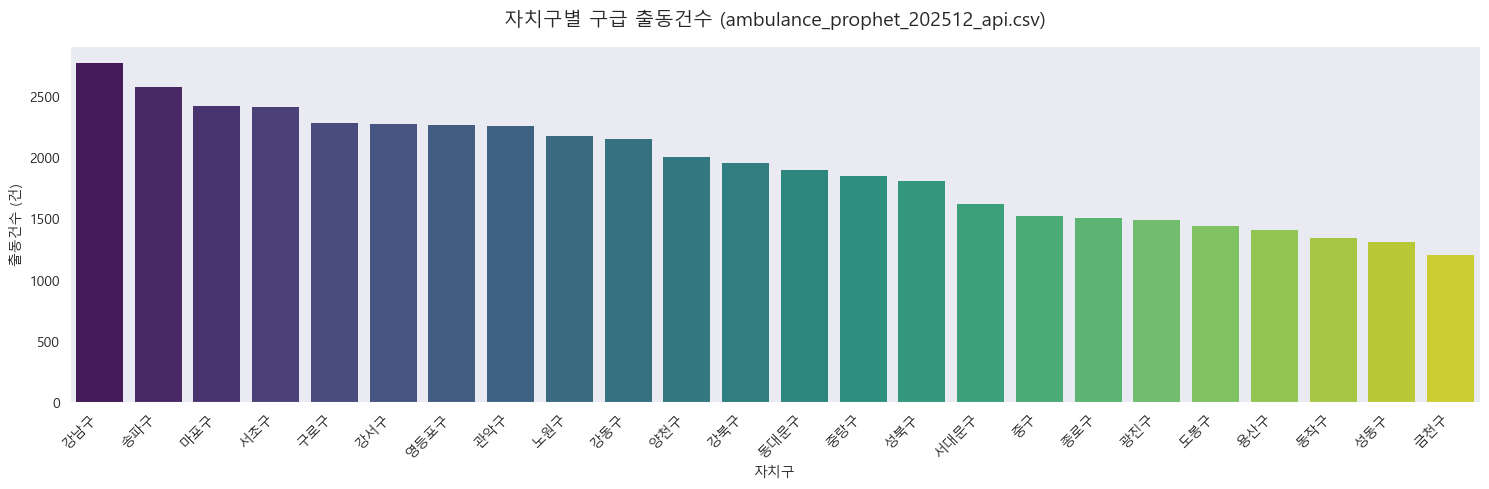

In [12]:
import numpy as np

# 자치구별 출동건수 막대그래프 (내림차순)
fig, ax = plt.subplots(figsize=(15, 5))

sns.barplot(
    data=fire_df, 
    x='District', 
    y='y', 
    hue='District',     
    dodge=False,      
    palette='viridis', 
    edgecolor='none', 
    linewidth=0, 
    ax=ax
)

ax.get_legend().remove()

ax.set_title(f'자치구별 구급 출동건수 ({data_source_label})', fontsize=14, pad=15)
ax.set_xlabel('자치구')
ax.set_ylabel('출동건수 (건)')
plt.xticks(rotation=45, ha='right')

plt.tight_layout()
plt.show()

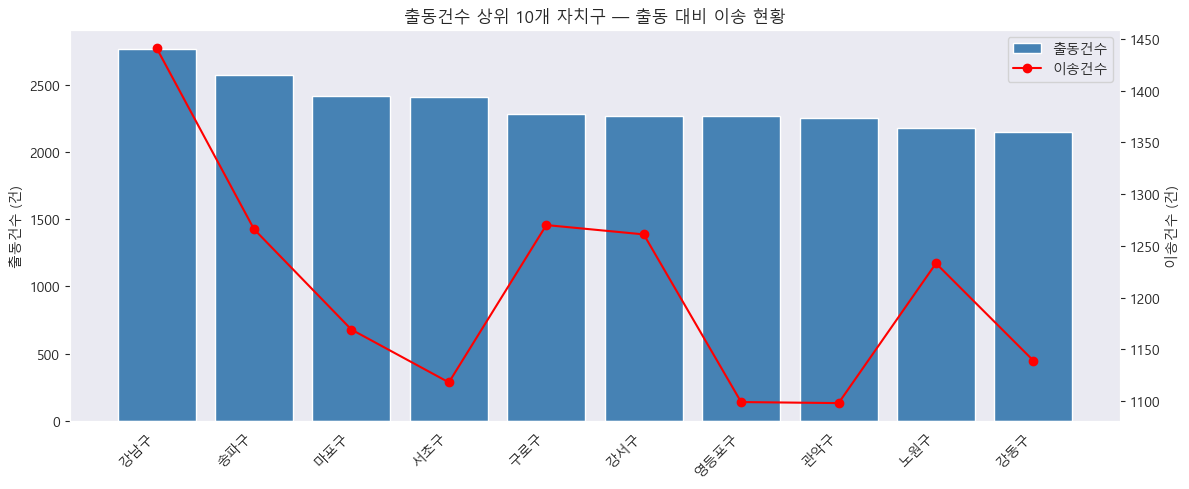

In [13]:
# 출동건수 대비 이송건수/이송환자수 비교 (상위 10개 구)
top10 = fire_df.head(10)

fig, ax1 = plt.subplots(figsize=(12, 5))
x = range(len(top10))
ax1.bar(x, top10['y'], color='steelblue', label='출동건수')
ax1.set_xticks(list(x))
ax1.set_xticklabels(top10['District'], rotation=45, ha='right')
ax1.set_ylabel('출동건수 (건)')
ax1.set_title('출동건수 상위 10개 자치구 — 출동 대비 이송 현황')

if 'transport_cnt' in top10.columns:
    ax2 = ax1.twinx()
    ax2.plot(x, top10['transport_cnt'], 'ro-', label='이송건수')
    ax2.set_ylabel('이송건수 (건)')
    lines1, labels1 = ax1.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper right')

plt.tight_layout()
plt.show()


---
## 2. 실시간 응급실 가용병상 API 결과 — 자치구별 가용병상 현황

`collect_realtime_beds_all_gu()` 결과(`realtime_er_beds.csv`)가 있어야 그릴 수 있습니다.
실제 병상 수치를 임의로 만들어 보여드리지 않으므로, 파일이 없으면 안내만 출력합니다.

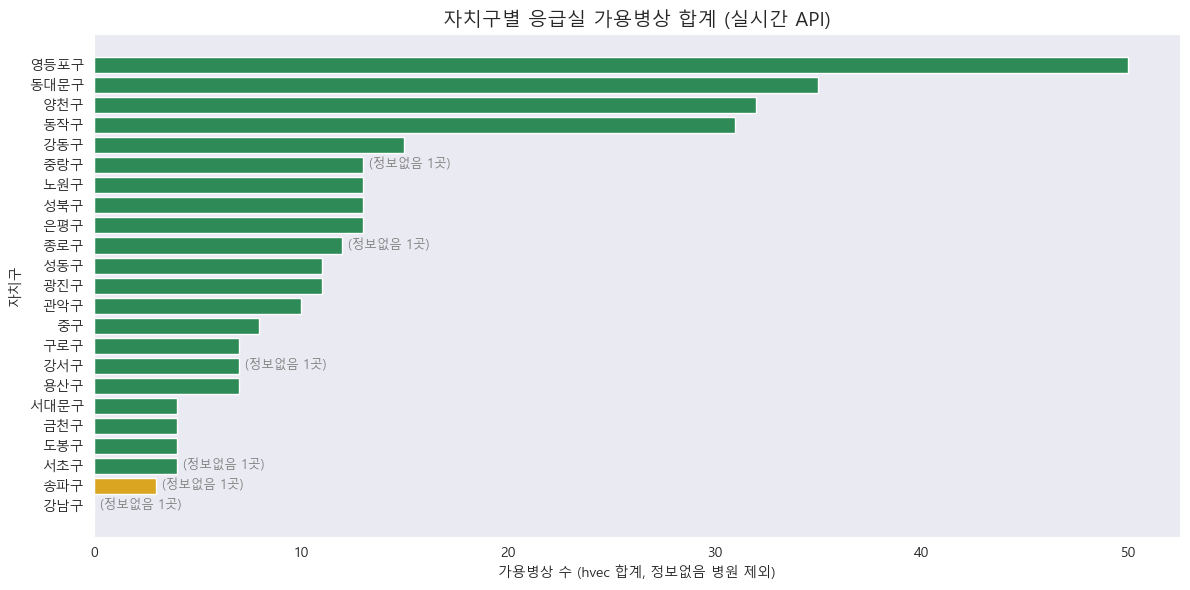

[범례] 빨강: 가용병상 0개 / 주황: 1~3개 / 초록: 4개 이상
수집 시각 범위: 2026-09-22 12:31:55.325679 ~ 2026-09-22 12:32:26.346463
[참고] 병상 정보를 보고하지 않은 병원 6곳은 합계에서 제외했습니다(음수=정보없음 코드).


In [14]:
bed_path = f"{OUT_DIR}/realtime_er_beds.csv"

if os.path.exists(bed_path):
    beds_df = pd.read_csv(bed_path)

    # [주의] 이 API는 병상 수가 음수(예: -1)로 오면 '정보 없음/미보고'를 뜻하는 특수 코드다.
    # API 노트북(fetch_realtime_er_beds)에서 이미 음수를 결측치(NaN)로 바꾸고 Beds_Unknown
    # 플래그를 남겨두므로, 여기서는 그 결측을 집계에서 제외(sum은 기본적으로 NaN을 건너뜀)하고
    # '정보없음' 병원 수를 별도로 보여준다. (구버전 CSV라 Beds_Unknown이 없으면 음수를 즉석에서 결측 처리)
    if 'Beds_Unknown' not in beds_df.columns:
        beds_df['Beds_Unknown'] = beds_df['Available_Beds'] < 0
        beds_df.loc[beds_df['Beds_Unknown'], 'Available_Beds'] = pd.NA
    beds_df['Available_Beds'] = pd.to_numeric(beds_df['Available_Beds'], errors='coerce')

    # 자치구 단위로 가용병상 합계 (병원이 여러 개인 구 존재, 결측은 sum에서 자동 제외됨)
    gu_beds = beds_df.groupby('District', as_index=False).agg(
        Available_Beds=('Available_Beds', 'sum'),
        Hospital_Count=('Hospital_Name', 'nunique'),
        Unknown_Count=('Beds_Unknown', 'sum'),
        Has_Ffilled=('is_ffilled', 'any')
    ).sort_values('Available_Beds')

    # 병상 부족(0개) 여부에 따라 색상 강조
    colors = ['crimson' if v == 0 else ('goldenrod' if v <= 3 else 'seagreen')
              for v in gu_beds['Available_Beds']]

    fig, ax = plt.subplots(figsize=(12, 6))
    ax.barh(gu_beds['District'], gu_beds['Available_Beds'], color=colors)
    ax.set_title('자치구별 응급실 가용병상 합계 (실시간 API)', fontsize=14)
    ax.set_xlabel('가용병상 수 (hvec 합계, 정보없음 병원 제외)')
    ax.set_ylabel('자치구')

    # ffill(직전 응답 대체)되었거나 정보없음 병원이 있는 구는 라벨에 표시
    for i, (ffilled, unk) in enumerate(zip(gu_beds['Has_Ffilled'], gu_beds['Unknown_Count'])):
        note = []
        if ffilled:
            note.append('직전값 대체')
        if unk > 0:
            note.append(f'정보없음 {unk}곳')
        if note:
            ax.text(gu_beds['Available_Beds'].iloc[i] + 0.3, i, '(' + ', '.join(note) + ')',
                    va='center', fontsize=9, color='gray')

    plt.tight_layout()
    plt.show()

    print("[범례] 빨강: 가용병상 0개 / 주황: 1~3개 / 초록: 4개 이상")
    print(f"수집 시각 범위: {beds_df['collected_at'].min()} ~ {beds_df['collected_at'].max()}")
    total_unknown = int(beds_df['Beds_Unknown'].sum())
    if total_unknown:
        print(f"[참고] 병상 정보를 보고하지 않은 병원 {total_unknown}곳은 합계에서 제외했습니다(음수=정보없음 코드).")
else:
    print("[안내] realtime_er_beds.csv가 아직 없습니다.")
    print("119_공공API_연동.ipynb에서 collect_realtime_beds_all_gu()를 실행하고")
    print(f"결과를 {bed_path} 로 저장한 뒤 이 셀을 다시 실행해주세요.")


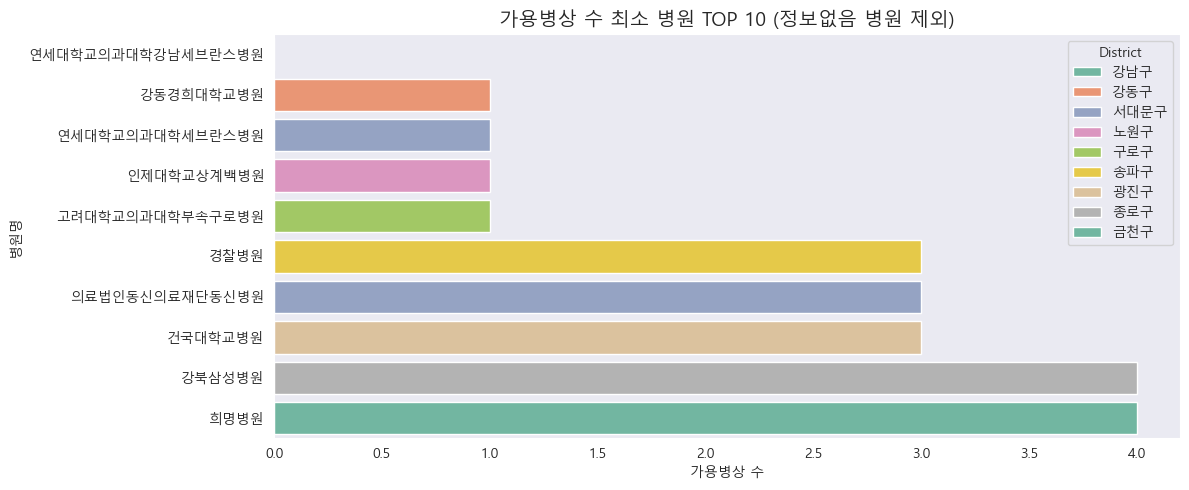

[참고] 병상 정보 미보고 병원 6곳 (이 TOP10에서 제외됨):


,District,Hospital_Name
1,강남구,삼성서울병원
5,강서구,이화여자대학교의과대학부속서울병원
25,서초구,학교법인가톨릭학원가톨릭대학교서울성모병원
29,송파구,재단법인아산사회복지재단서울아산병원
43,종로구,서울대학교병원
50,중랑구,녹색병원


In [15]:
# 병원 단위 상세 (가용병상 적은 순 TOP 10, 정보없음 병원 제외) - 파일이 있을 때만 실행됨
if os.path.exists(bed_path):
    known_beds = beds_df[~beds_df['Beds_Unknown']].copy()
    low_beds = known_beds.sort_values('Available_Beds').head(10)

    fig, ax = plt.subplots(figsize=(12, 5))
    sns.barplot(data=low_beds, x='Available_Beds', y='Hospital_Name', hue='District',
                dodge=False, palette='Set2', ax=ax)
    ax.set_title('가용병상 수 최소 병원 TOP 10 (정보없음 병원 제외)', fontsize=14)
    ax.set_xlabel('가용병상 수')
    ax.set_ylabel('병원명')
    plt.tight_layout()
    plt.show()

    if beds_df['Beds_Unknown'].any():
        unknown_hospitals = beds_df[beds_df['Beds_Unknown']][['District', 'Hospital_Name']]
        print(f"[참고] 병상 정보 미보고 병원 {len(unknown_hospitals)}곳 (이 TOP10에서 제외됨):")
        display(unknown_hospitals)


---
## 정리

- 1번 섹션은 소방청 API(또는 대체용 정적 데이터)로 **자치구별 구급 수요**를,
- 2번 섹션은 국립중앙의료원 API로 **자치구별 응급실 수용 여력**을 보여줍니다.

두 시각화를 나란히 보면 "구급 출동이 많은 지역인데 응급실 가용병상은 부족한가?" 같은
이 프로젝트의 핵심 질문(구급 수요 ↔ 응급실 수용력 매칭)에 바로 활용할 수 있습니다.